Choose distance unit to display
1 - Kilometers
2 - Miles


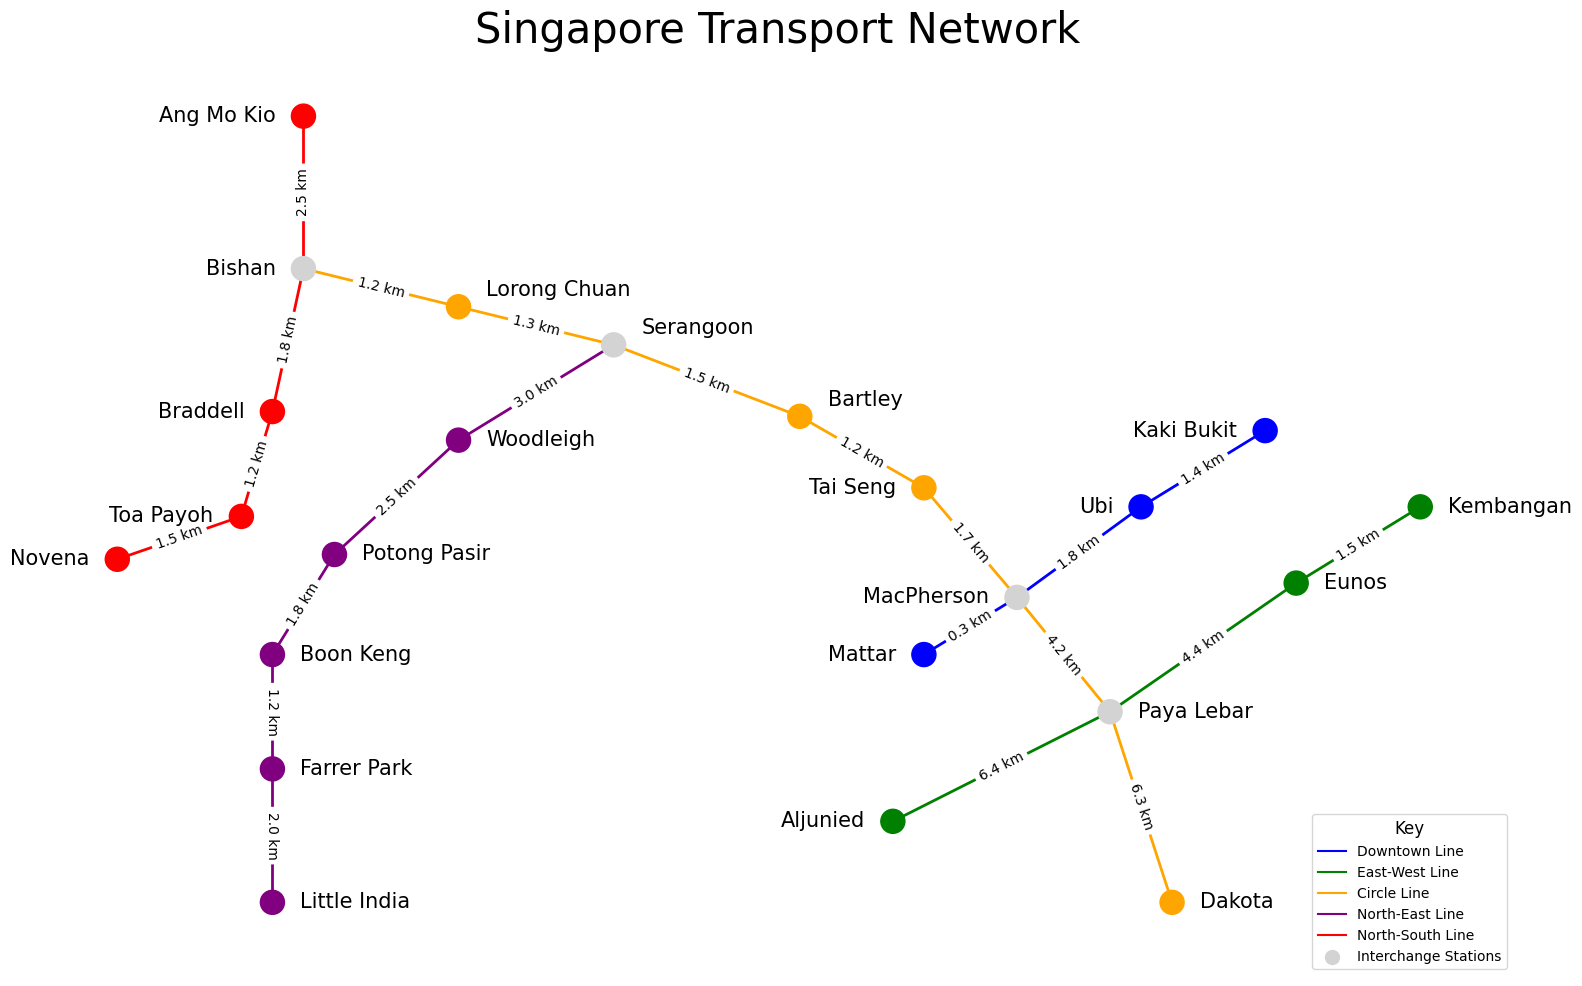

In [4]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

print("Choose distance unit to display")
print("1 - Kilometers")
print("2 - Miles")

choice = input("Enter choice: ")

if choice == "1":
    distance_type = "km"
else:
    distance_type = "mi"

# Create graph
G = nx.Graph()

edges = [
    ("Mattar", "MacPherson", 0.3),
    ("MacPherson", "Ubi", 1.8),
    ("Ubi", "Kaki Bukit", 1.4),
    
    ("Aljunied", "Paya Lebar", 6.4),
    ("Paya Lebar", "Eunos", 4.4),
    ("Eunos", "Kembangan", 1.5),
    
    ("Tai Seng", "MacPherson", 1.7),
    ("MacPherson", "Paya Lebar", 4.2),
    ("Paya Lebar", "Dakota", 6.3),
    ("Tai Seng", "Bartley", 1.2),
    ("Bartley", "Serangoon", 1.5),
    ("Lorong Chuan", "Serangoon", 1.3),
    ("Lorong Chuan", "Bishan", 1.2),
    
    ("Serangoon", "Woodleigh", 3.0),
    ("Woodleigh", "Potong Pasir", 2.5),
    ("Potong Pasir", "Boon Keng", 1.8),
    ("Boon Keng", "Farrer Park", 1.2),
    ("Farrer Park", "Little India", 2.0),
    
    ("Ang Mo Kio", "Bishan", 2.5),
    ("Bishan", "Braddell", 1.8),
    ("Braddell", "Toa Payoh", 1.2),
    ("Toa Payoh", "Novena", 1.5),
]

for u, v, km in edges:
    mi = km * 0.621371
    G.add_edge(
        u, v,
        km=km,
        mi=round(mi,2)
    )


# Node positions
pos = {
    "Mattar": (1.6, 1.2),
    "MacPherson": (1.9, 2.4),
    "Ubi": (2.3, 4.3),
    "Kaki Bukit": (2.7, 5.9),

    "Tai Seng": (1.6, 4.7),
    "Bartley": (1.2, 6.2),
    "Serangoon": (0.6, 7.7),
    "Lorong Chuan": (0.1, 8.5),
    "Bishan": (-0.4, 9.3),

    "Paya Lebar": (2.2, 0),
    "Dakota": (2.4, -4),

    "Aljunied": (1.5, -2.3),
    "Eunos": (2.8, 2.7),
    "Kembangan": (3.2, 4.3),
    
    "Woodleigh": (0.1, 5.7),
    "Potong Pasir": (-0.3, 3.3),
    "Boon Keng": (-0.5, 1.2),
    "Farrer Park": (-0.5, -1.2),
    "Little India": (-0.5, -4.0),
    
    "Ang Mo Kio": (-0.4, 12.5),
    "Braddell": (-0.5, 6.3),
    "Toa Payoh": (-0.6, 4.1),
    "Novena": (-1, 3.2)
}


node_colors = []
for node in G.nodes():
    if node in ["Mattar", "Ubi", "Kaki Bukit"]:
        node_colors.append("blue")
        
    elif node in ["Aljunied", "Eunos", "Kembangan"]:
        node_colors.append("green")
    
    elif node in ["Woodleigh", "Potong Pasir", "Boon Keng", "Farrer Park", "Little India"]:
        node_colors.append("purple")

    
    elif node in ["Ang Mo Kio", "Braddell", "Toa Payoh", "Novena"]:
        node_colors.append("red")
    
    elif node in ["Tai Seng", "Dakota", "Bartley", "Lorong Chuan"]:
        node_colors.append("orange")
    else:
        node_colors.append("lightgrey")
        
    
        
plt.figure(figsize=(19,12))

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=300)

# Draw edges
nx.draw_networkx_edges(G, pos,
                       edgelist=[("Mattar","MacPherson"),("MacPherson","Ubi"),("Ubi","Kaki Bukit")],
                       width=2, edge_color="blue")

nx.draw_networkx_edges(G, pos,
                       edgelist=[("Aljunied","Paya Lebar"),("Paya Lebar","Eunos"),("Eunos","Kembangan")],
                       width=2, edge_color="green")

nx.draw_networkx_edges(G, pos,
                          edgelist=[("Woodleigh","Serangoon"),("Woodleigh","Potong Pasir"),
                                    ("Potong Pasir","Boon Keng"),("Boon Keng","Farrer Park"),("Farrer Park","Little India")],
                          width=2, edge_color="purple")

nx.draw_networkx_edges(G, pos,
                       edgelist=[("Tai Seng","MacPherson"),("MacPherson","Paya Lebar"),("Paya Lebar","Dakota"),
                                 ("Tai Seng","Bartley"),("Bartley","Serangoon"), ("Lorong Chuan","Serangoon"), ("Lorong Chuan","Bishan")],
                       width=2, edge_color="orange")

nx.draw_networkx_edges(G, pos,
                       edgelist=[("Ang Mo Kio","Bishan"),("Bishan","Braddell"),("Braddell","Toa Payoh"),("Toa Payoh","Novena")],
                       width=2, edge_color="red")


edge_labels = {}

for u,v,data in G.edges(data=True):
    edge_labels[(u,v)] = str(data[distance_type]) + " " + distance_type

nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels)


offset = 0.09

y_nudge = {
    "Lorong Chuan": 0.35,
    "Serangoon":    0.35,
    "Bartley":      0.35,
}
 
for node, (x, y) in pos.items():
 
    dy = y_nudge.get(node, 0)   # extra vertical offset for specific nodes
 
    if node in ["Mattar", "Tai Seng", "Aljunied", "Kaki Bukit", "Ubi", "MacPherson",
                "Ang Mo Kio", "Bishan", "Braddell", "Toa Payoh", "Novena"]:
        plt.text(x - offset, y + dy, node,
                 horizontalalignment='right',
                 verticalalignment='center',
                 fontsize=15)
 
    elif node in ["Eunos", "Kembangan", "Paya Lebar", "Dakota", "Bartley", "Serangoon", 
                  "Woodleigh", "Potong Pasir", "Boon Keng", "Farrer Park", "Little India", "Lorong Chuan"]:
        plt.text(x + offset, y + dy, node,
                 horizontalalignment='left',
                 verticalalignment='center',
                 fontsize=15)


# Legend
plt.plot([],[],color="blue",label="Downtown Line")
plt.plot([],[],color="green",label="East-West Line")
plt.plot([],[],color="orange",label="Circle Line")
plt.plot([],[],color="purple",label="North-East Line")
plt.plot([],[],color="red",label="North-South Line")
plt.scatter([], [], color="lightgrey", s=100, label="Interchange Stations")

plt.legend(title="Key",loc="lower right", title_fontsize=12)

plt.axis("off")
plt.title("Singapore Transport Network", fontsize=30)
plt.show()

# Task 2

In [5]:
all_km    = np.array([data["km"] for _, _, data in G.edges(data=True)])
all_mi    = np.array([data["mi"] for _, _, data in G.edges(data=True)])
 
total_km    = round(float(np.sum(all_km)),  2)
total_mi    = round(float(np.sum(all_mi)),  2)
avg_km      = round(float(np.mean(all_km)), 2)
avg_mi      = round(float(np.mean(all_mi)), 2)

df = pd.DataFrame(
    {
        "Kilometers": [total_km, avg_km],
        "Miles":      [total_mi, avg_mi],
    },
    index=["Total length of transport network", "Average distance between stations"]
)
 
print("\n=== Task 2 – Network Statistics ===\n")
print(df.to_string())



=== Task 2 – Network Statistics ===

                                   Kilometers  Miles
Total length of transport network        50.7  31.51
Average distance between stations         2.3   1.43
